<a href="https://colab.research.google.com/github/yemioz/Numerical-Methods-Projects/blob/main/riemann-and-trapezoid-integraiton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Integration

This notebook covers and compares integration using both Reimann and Trapezoid methods. 

Below are imported packages that will support the functions and expressions needed for the coding throughout this project.

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate

# Riemann Integration

Riemann sums are used to compute the area under a curve using rectangles.

Using our original function of:$$f(x)=4e^{-x}$$
We will graph and find the area under the curve on the interval $0\le x\le4$.

In [ ]:
function = lambda x: 4*np.exp(-x)

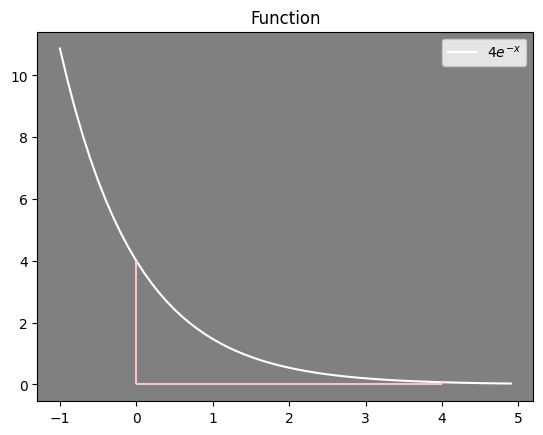

In [ ]:
x = np.arange(-1, 5, .1)
ax = plt.axes()
ax.set_facecolor('grey')
plt.plot(x, function(x), c = 'white')
plt.vlines(x = 0, ymin = 0, ymax = function(0), color = 'pink')
plt.vlines(x = 4, ymin = 0, ymax = function(4), color = 'pink')
plt.hlines(y = 0, xmin = 0, xmax = 4, color = 'pink')
plt.title('Function')
plt.legend(['$4e^{-x}$'])

In [ ]:
function = lambda x: 4*np.exp(-x)
step = 1/2
endpoints = [1/2, 1, 3/2, 2, 5/2, 3, 7/2, 4]

def Reimann(function, endpoints, step):
  area = 0
  for i in endpoints:
    area = area + function(i)*step
  return area

Reimann(function, endpoints, step)

3.0265212671438673

We will now check our answer using 8 right endpoints for more accuracy.


In [ ]:
integrate.quad(function, 0, 4)

(3.9267374444450636, 4.3595543224806564e-14)

We will now create an algorithm to compute the Riemann sum of our function over the interval $0\le x\le4$ using the right endpoints.

In [ ]:
def Reimann_2(function, start, stop, rectangles):
  right_endpoints = []
  delta_x = (stop-start)/rectangles
  for i in range(1, rectangles+1):
    right_endpoints.append(i*delta_x)

  area = 0
  for i in right_endpoints:
    area = area + function(i)*delta_x
  return area

In [ ]:
Reimann_2(function, 0, 4, 8)

3.0265212671438673


Below is a table of the errors in our estimate using several different numbers of rectangles and scipy's integrate.quad method as our true value.

In [ ]:
def true_error(true_value, approx_values):
  errors = []
  for i in approx_values:
    errors.append(abs(true_value - i))
  return errors


rectangles = [8, 12, 16, 20, 24, 28, 50, 100, 250, 500]
true_value = integrate.quad(function, 0, 4)[0]
approx = [Reimann_2(function, 0, 4, i) for i in rectangles]
error = true_error(true_value, approx)

integral_approx = {'Rectangles': [rect for rect in rectangles],
        'Approximation': approx,
        'Error': error}

integral_table = pd.DataFrame(integral_approx)
print(integral_table)

   Rectangles  Approximation     Error
0           8       3.026521  0.900216
1          12       3.308573  0.618165
2          16       3.456326  0.470412
3          20       3.547144  0.379593
4          24       3.608595  0.318143
5          28       3.652932  0.273805
6          50       3.771762  0.154975
7         100       3.848726  0.078011
8         250       3.895407  0.031330
9         500       3.911051  0.015686


As you can see, the more rectangles used, the better the approximation gets.

### Trapezoid Rule

The trapezoid rule evaluates the area under the curve by dividing the total area into smaller trapezoids rather than using rectangles. The formula is given below:
$$ \int_a^b f(x)\ dx \approx \frac{\Delta x}{2} \left[ f(a)+2\left( \sum_{i=1}^{n-1} f(a+i\Delta x) \right)+f(b) \right] $$

In [ ]:
def trap(function, start, stop, step):
  area = 0
  sum = 0
  n = stop-start
  for i in range(1, n):
    sum = sum + function(start+i*step)
  area = (step/2)*(function(start)+2*sum+function(stop))
  return area

In [ ]:
trap(function, 0, 4, 1/2)

3.4133961609537455

We will now compute the errors on our function and compare it to our other estimates. We will use multiple step sizes and use scipy's integrate.quad methos as our true value.

In [ ]:
trap_values = [1/4, 1/3, 1/2, 1, 3/2]
trap_approx = [trap(function, 0, 4, i) for i in trap_values]
trap_error = true_error(true_value, trap_approx)

trap_integral = {'Step': [trap for trap in trap_values],
        'Approximation': trap_approx,
        'Error': trap_error}

trap_table = pd.DataFrame(trap_integral)
print(trap_table)

       Step  Approximation     Error
0  0.250000       2.366856  1.559882
1  0.333333       2.809314  1.117423
2  0.500000       3.413396  0.513341
3  1.000000       4.248638  0.321901
4  1.500000       4.759104  0.832367


It seems that using the value 1 gives us the best approximation with the smallest error.

### Findings


Since we were using right endpoints in our first approximation, we always ended up with our approximation being under the true value. This is due to the nature of our graph, which is purely a negative slope, and using right endpoints on a negative slope will always result in the lowest estimate.

The trapezoidal approximation was also an underestimate, but this is for a different reason. When using the trapezoidal approximation, an estimate is less than the true value if the derivative of the slope is positive, leading to a kind of hole or divot in our graph.

When it comes to when to choose left or right endpoints, it depends on the positivity of your function as well as whether you want an overestimate or an underestimate. If you want an overestimate, then choose right endpoints for positive and left for negative. For an underestimate, choose left for positive graphs and right for negative ones. For undulating graphs, determine if the graph is more positive slope or more negative slope, then follow the rules above.